# Hamiltonian Flow Matching - Interaction Potential (2D)

Transports a Gaussian source to a Gaussian target under a mean-field interaction potential configured through `Potential`.
The interaction kernel is the configured `rational_quadratic` pairwise kernel.

The conditional path uses `MeanStdBVPGaussianPath` with scalar standard deviation. Before solving the BVPs, the path samples a frozen empirical reference density `Y_ref(t)` from the family of Gaussian paths. During SciPy RHS calls, `Y_ref(t)` is retrieved by linear interpolation on the reference grid. The interaction contributes to both the mean acceleration `mu''(t)` and the scalar-projected standard-deviation acceleration `sigma''(t)`.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))

import torch
device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
import numpy as np
import matplotlib.pyplot as plt
from torchdyn.core import NeuralODE
from torch.distributions import MultivariateNormal
from torchcfm.hamiltonian import (
    ConfiguredPotential, MeanStdBVPGaussianPath, flow_matching_loss,
    plot_trajectories_with_potential,
)
from torchcfm.optimal_transport import OTPlanSampler
from torchcfm.models.models_v2 import MLP
from torchcfm.utils import sample_8gaussians, sample_moons, torch_wrapper

def to_numpy(x):
    return x.detach().cpu().numpy()

In [2]:

torch.manual_seed(42)

dim          = 2
batch_size   = 64
n_dataset    = 512   # number of pre-computed (x0, x1) pairs
n_iters      = 10_000
lr           = 1e-3
sigma_path   = 0.01
n_steps      = 150
tol          = 0.1
n_density_samples = 16

source_mean  = torch.tensor([-11.0, -1.0],device = device)
target_mean  = torch.tensor([11.0, 1.0],device = device)
gaussian_std = torch.tensor(0.5,device = device)
print(f'device: {device}')

device: cuda:2


In [3]:
source_dist = MultivariateNormal(source_mean, gaussian_std**2 * torch.eye(dim).to(device))
target_dist = MultivariateNormal(target_mean, gaussian_std**2 * torch.eye(dim).to(device))

def sample_source(n):
    return source_dist.sample((n,)).to(device)

def sample_target(n):
    return target_dist.sample((n,)).to(device)

cfg_potential = {
    "linear": None,
    "internal": None,
    "interaction": ("rational_quadratic", -10.0),
}
potential = ConfiguredPotential(cfg_potential)


In [4]:
path = MeanStdBVPGaussianPath(
    potential,
    sigma=sigma_path,
    n_steps=n_steps,
    tol=tol,
    n_density_samples=n_density_samples,
)
ot_sampler = OTPlanSampler(method='exact')

# Step 1: OT-couple the dataset.
x0_all = sample_source(n_dataset)
x1_all = sample_target(n_dataset)
x0_coupled, x1_coupled = ot_sampler.sample_plan(x0_all, x1_all)

print(
    f'Solving {n_dataset} mean/std BVPs with {n_density_samples} frozen reference-density samples '
    f'(may take several minutes)...'
)

# Step 2: Pre-compute BVP for all pairs and drop non-converged solves.
states = path.batch_solve(x0_coupled, x1_coupled)
keep = path.success_mask
x0_coupled = x0_coupled[keep]
x1_coupled = x1_coupled[keep]
n_failed = int((~keep).sum().item())
n_dataset = x0_coupled.shape[0]
print(
    f'Done. kept {n_dataset} / {keep.numel()} BVPs; failed {n_failed}. '
    f'states: {states.shape}  (pairs, time-steps, state-dim [mu, mu_dot, sigma, sigma_dot]); '
    f'Y_ref: {path.reference_samples.shape if path.reference_samples is not None else None}'
)
if n_failed:
    preview = list(path.failure_messages.items())[:5]
    print(f'First failures: {preview}')


Solving 512 mean/std BVPs with 16 frozen reference-density samples (may take several minutes)...
Done. kept 399 / 512 BVPs; failed 113. states: torch.Size([399, 151, 6])  (pairs, time-steps, state-dim [mu, mu_dot, sigma, sigma_dot]); Y_ref: (151, 16, 2)
First failures: [(6, 'The maximum number of mesh nodes is exceeded.'), (7, 'SciPy mean/std BVP returned a nonpositive sigma path.'), (8, 'The maximum number of mesh nodes is exceeded.'), (20, 'The maximum number of mesh nodes is exceeded.'), (22, 'The maximum number of mesh nodes is exceeded.')]


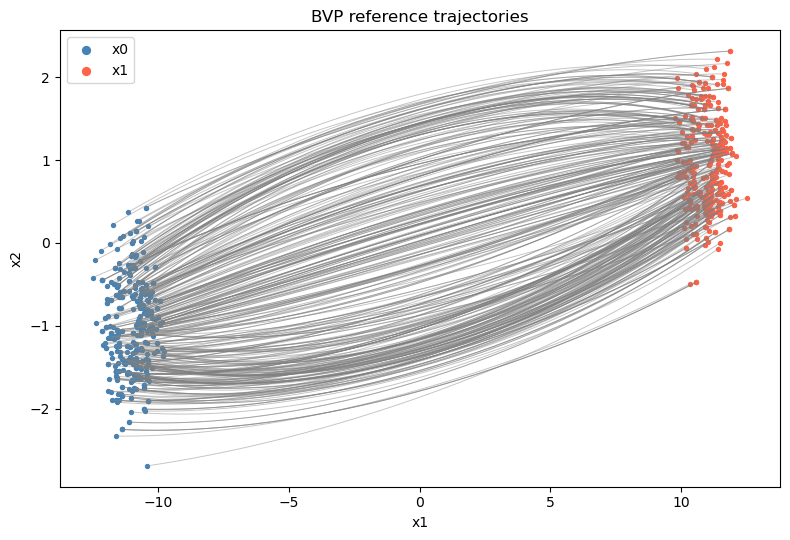

In [5]:
# Visualize a few BVP-solved trajectories.
n_show = min(n_dataset, n_dataset)
traj_bvp = to_numpy(states[:n_show, :, :dim])  # (pairs, time, x-position)
x0_coupled_plot = to_numpy(x0_coupled[:n_show])
x1_coupled_plot = to_numpy(x1_coupled[:n_show])

plt.figure(figsize=(8, 5.5))

for i in range(n_show):
    plt.plot(traj_bvp[i, :, 0], traj_bvp[i, :, 1], 'gray', alpha=0.45, linewidth=0.7)
plt.scatter(x0_coupled_plot[:, 0], x0_coupled_plot[:, 1], s=8, c='steelblue', label='x0')
plt.scatter(x1_coupled_plot[:, 0], x1_coupled_plot[:, 1], s=8, c='tomato', label='x1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(markerscale=2)

plt.title('BVP reference trajectories')
plt.tight_layout()
plt.show()

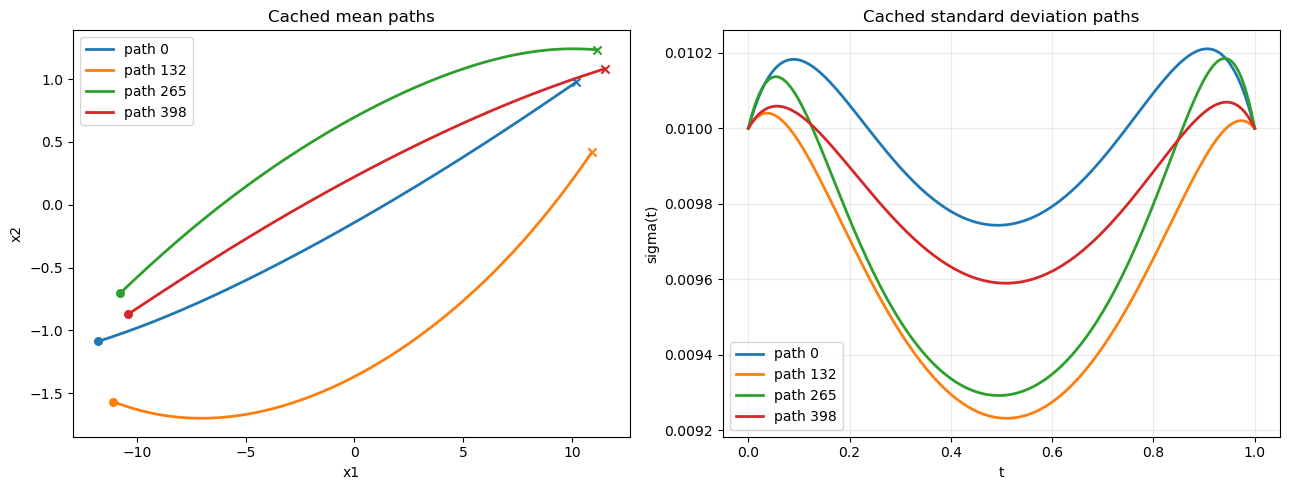

In [6]:
# Plot four cached mean paths and their standard deviation schedules.
n_mean_std_show = min(4, states.shape[0])
plot_idx = torch.linspace(0, states.shape[0] - 1, n_mean_std_show).long()
t_state = to_numpy(path.t_grid[:states.shape[1]])
mean_paths = to_numpy(states[plot_idx, :, :dim])
sigma_paths = to_numpy(states[plot_idx, :, 2 * dim])
colors = plt.cm.tab10(np.arange(n_mean_std_show))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


for j, idx in enumerate(plot_idx.tolist()):
    axes[0].plot(mean_paths[j, :, 0], mean_paths[j, :, 1], color=colors[j], linewidth=2.0, label=f'path {idx}')
    axes[0].scatter(mean_paths[j, 0, 0], mean_paths[j, 0, 1], s=30, color=colors[j], marker='o')
    axes[0].scatter(mean_paths[j, -1, 0], mean_paths[j, -1, 1], s=35, color=colors[j], marker='x')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title('Cached mean paths')
axes[0].legend()

for j, idx in enumerate(plot_idx.tolist()):
    axes[1].plot(t_state, sigma_paths[j], color=colors[j], linewidth=2.0, label=f'path {idx}')
axes[1].set_xlabel('t')
axes[1].set_ylabel('sigma(t)')
axes[1].set_title('Cached standard deviation paths')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


## Model and training

In [7]:
model = MLP(dim + 1, out_dim=dim, w=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

x0_coupled = x0_coupled.to(device)
x1_coupled = x1_coupled.to(device)

model.train()
losses = []

for k in range(n_iters):
    optimizer.zero_grad()

    idx = torch.randint(0, n_dataset, (batch_size,), device=device)
    x0_b = x0_coupled[idx]
    x1_b = x1_coupled[idx]

    t = torch.rand((batch_size, 1), device=device)
    epsilon = torch.randn_like(x0_b)
    xt = path.sample_xt(x0_b, x1_b, t, epsilon)
    ut = path.compute_ut(x0_b, x1_b, t, xt)

    vt = model(torch.cat([xt, t], dim=-1))
    loss = flow_matching_loss(vt, ut)

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if k % 1000 == 0 or k == n_iters - 1:
        print(f'step {k:5d}: loss = {loss.item():.5f}')

step     0: loss = 242.86873
step  1000: loss = 0.80396
step  2000: loss = 0.65117
step  3000: loss = 0.67252
step  4000: loss = 0.45491
step  5000: loss = 0.33784
step  6000: loss = 0.25809
step  7000: loss = 0.24393
step  8000: loss = 0.14268
step  9000: loss = 0.14869
step  9999: loss = 0.18498


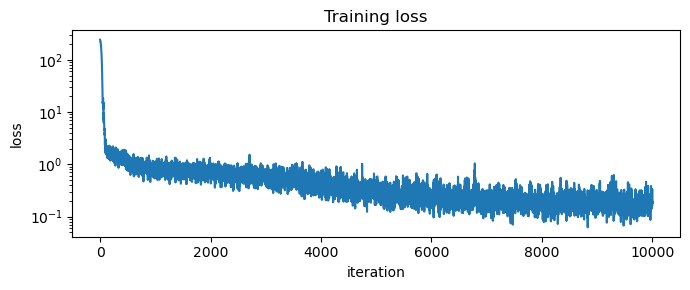

In [8]:
plt.figure(figsize=(7, 3))
plt.semilogy(losses)
plt.xlabel('iteration'); plt.ylabel('loss'); plt.title('Training loss')
plt.tight_layout(); plt.show()

## Evaluation

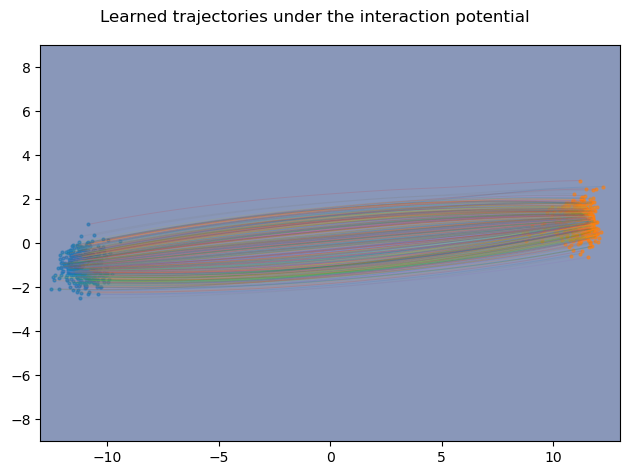

In [9]:
model.eval()
node = NeuralODE(torch_wrapper(model), sensitivity='adjoint', solver='euler')

with torch.no_grad():
    traj = node.trajectory(
        sample_source(500).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )

traj_plot = to_numpy(traj)
x_grid = np.linspace(-13, 13, 180)
y_grid = np.linspace(-9, 9, 140)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.zeros_like(X)
fig = plot_trajectories_with_potential(traj_plot, X, Y, Z, n=500)
fig.suptitle('Learned trajectories under the interaction potential')
plt.tight_layout()
plt.show()


# x1_ref = to_numpy(sample_target(500))
# plt.figure(figsize=(7, 5.5))
# plt.scatter(traj_plot[-1, :, 0], traj_plot[-1, :, 1], s=5, c='tomato', label='generated')
# plt.scatter(x1_ref[:, 0], x1_ref[:, 1], s=5, c='seagreen', label='target')
# plt.xlabel('x1')
# plt.ylabel('x2')
# plt.legend(markerscale=2)
# plt.title('Generated terminal samples vs target')
# plt.tight_layout()
# plt.show()